# Q 01

In [226]:
x = [117]
a = 43
m =1000
x1 = a*x[0]%m
x.append(x1)
for i in range(1, len(x)):
    if x[-1] != x[0]:
        x1 = a*x[i] % m
        x.append(x1)
    else: 
        break
r = [x[i]/1000 for i in range(len(x))]
r


[0.117, 0.031, 0.333]

# Q 02

In [233]:
from scipy.stats import ks_1samp


D_plus = []
D_minus = []
r = [0.594, 0.928, 0.515, 0.055, 0.507, 0.351, 0.262, 0.797, 0.788, 0.442, 0.097, 0.798, 0.227, 0.127, 0.474, 0.825, 0.007, 0.182, 0.929, 0.852]
r.sort()

for i in range(len(r)):
    e = (i + 1)/len(r)
    d = e - r[i]
    if d >= 0:
        D_plus.append(d)
    else:
        D_plus.append(0)
    d_down = r[i] - (i)/len(r)
    if d_down >= 0:
        D_minus.append(d_down)
    else:
        D_minus.append(0)

max_D = [max(D_plus), max(D_minus)]
max_ = max(max_D)

if max_ < 0.32866:
    print("uniform")

uniform


# Q 03

In [228]:
import pandas as pd

cdf = []
slope = []
end = [30, 15, 15, 30, 30, 160, 120]
frequency = [10, 20, 25, 35, 30, 20, 10]
pdf = [frequency[i]/sum(frequency) for i in range(len(frequency))]
for i in range(len(pdf)):
    cdf.append(sum(pdf[0:i+1]))
slope.append(cdf[0]/end[0])
for i in range(1, len(cdf)):
    slope.append((cdf[i]-cdf[i-1])/end[i])


di = {"interval":["14_30", "30_45", "45_60", "60-90", "90_120","120_180","180_300"], "N":frequency, "prob":pdf, "CDF":cdf, "slope": slope }

df = pd.DataFrame(di)
df

,interval,N,prob,CDF,slope
0,14_30,10,0.066667,0.066667,0.002222
1,30_45,20,0.133333,0.200000,0.008889
2,45_60,25,0.166667,0.366667,0.011111
3,60-90,35,0.233333,0.600000,0.007778
4,90_120,30,0.200000,0.800000,0.006667
5,120_180,20,0.133333,0.933333,0.000833
6,180_300,10,0.066667,1.000000,0.000556


# Q 04

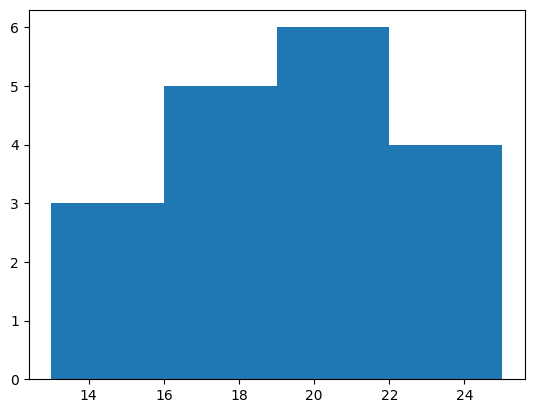

In [229]:
import matplotlib.pyplot as plt
import math
import numpy as np

num_customer = [20, 25, 21, 23, 18, 18, 18, 13, 18, 26, 27, 22, 14, 18, 21, 14, 20, 21, 25, 21]
days = [i for i in range(len(num_customer))]
bins = [13, 16, 19, 22, 25]


plt.hist(num_customer, bins)
plt.show()






In [230]:
def normal_inverse(mean, std, rv):
    z = (-2*math.log(rv))**2*math.cos(2*math.pi*rv)
    x = mean + z*std
    return x

rv = 0.71
print(normal_inverse(np.mean(num_customer), np.std(num_customer), rv))

19.703727891732235


# Q 05

In [231]:
import math
import numpy as np

li = [4.2, 4.4, 3.8, 4.42, 4.03, 3.75, 4.1]

def calculate_point_estimation(observations): 
    return(sum(observations)/len(observations))


def calculate_interval_estimation(observations,t_stat=2.26216,rounding=3): 
    n = len(observations)
    point_est = calculate_point_estimation(observations)
    sigma = (sum([(obs - (sum(observations)/n))**2 for obs in observations])/(n*(n-1)))**0.5
    if rounding==0:
        lower_bound = math.floor(point_est - (t_stat*sigma))
        lower_bound = max(0,lower_bound)
        upper_bound = math.ceil(point_est + (t_stat*sigma))
    else:
        lower_bound = round(point_est - (t_stat*sigma),rounding)
        lower_bound = max(0,lower_bound)
        upper_bound = round(point_est + (t_stat*sigma),rounding)
    return((lower_bound,upper_bound))

print(calculate_interval_estimation(li))
print(calculate_point_estimation(li))

if calculate_interval_estimation(li)[0] <= calculate_point_estimation(li) <= calculate_interval_estimation(li)[1]:
    print("simulation correct")
else:
    print("simulation incorrect!")

(3.874, 4.326)
4.1000000000000005
simulation correct


# Q 06

In [232]:
import math

def normal_inverse(mean, std, rv):
    z = (-2*math.log(rv))**2*math.cos(2*math.pi*rv)
    x = mean + z*std
    return x

def uniform_inverse(low, high, rv):
    x = low + (high - low)*rv
    return x

rv = 0.38

num_trucks = round(uniform_inverse(3, 7, rv))
num_trucks

load_time = []
rv_list = [0.88, 0.29, 0.53, 0.49, 0.63]

for i in range(num_trucks):
    load_time.append(round(normal_inverse(34, 5, rv_list[i])))

print(f"{num_trucks}\n{load_time}")


5
[34, 26, 26, 24, 31]
